In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [3]:
from sklearn.datasets import load_diabetes


In [6]:
diabetes = load_diabetes()
X = pd.DataFrame(diabetes['data'])
y= diabetes['target']

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=10)

<Axes: >

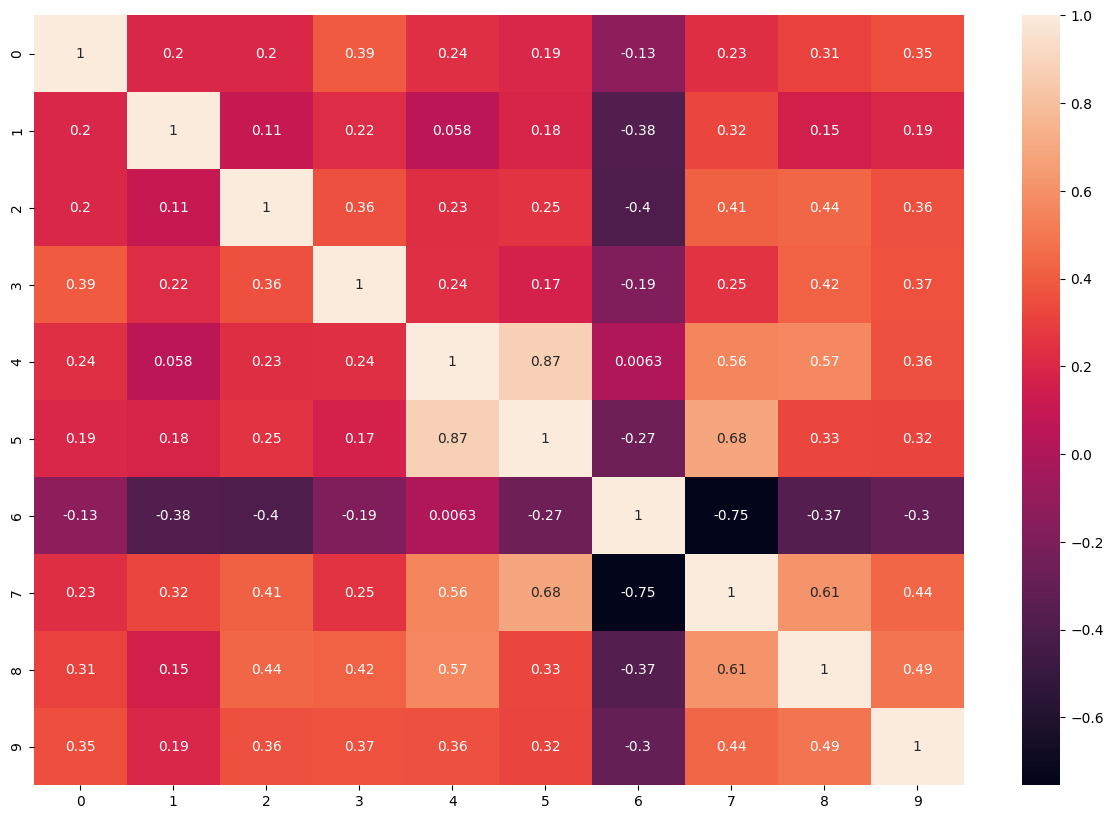

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(15,10))
sns.heatmap(X_train.corr(),annot=True)

In [11]:
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor()
regressor.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [ ]:
param={
    'criterion':['squared_error','friedman_mse','absolute_error'],
    'splitter':['best','random'],
    'max_depth':[1,2,3,4,5,10,15,20,25],
    'max_features':['auto','sqrt','log2']
}

    # max_features: Features considered for each split
    # - 'auto': Same as 'sqrt' for trees (√n_features random features)
    # - 'sqrt': ~√n_features random features per split
    # - 'log2': ~log₂(n_features) random features per split
    # None (not included) = all features
    
        # max_depth: Maximum tree depth
    # Controls overfitting - deeper = more complex, shallower = simpler
    # [1,2,3,4,5] = small trees | [10,15,20,25] = deeper trees
    
        # splitter: Strategy to choose split at each node
    # - 'best': Greedy approach - always picks best split (slower but more accurate)
    # - 'random': Faster - samples random splits, adds randomness
    
        # criterion: Function to measure split quality
    # - 'squared_error': MSE (default) - good for regression, penalizes large errors more
    # - 'friedman_mse': Modified MSE from Friedman - better for gradient boosting
    # - 'absolute_error': MAE - robust to outliers

In [14]:
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

grid=GridSearchCV(regressor,param_grid=param,cv=5,scoring='neg_mean_squared_error')
grid.fit(X_train,y_train)

,estimator,DecisionTreeRegressor()
,param_grid,"{'criterion': ['squared_error', 'friedman_mse', ...], 'max_depth': [1, 2, ...], 'max_features': ['auto', 'sqrt', ...], 'splitter': ['best', 'random']}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'friedman_mse'


In [15]:
y_pred=grid.predict(X_test)

In [16]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

0.38154589830766006
49.54004154383627
3913.374142881864


In [18]:
grid.best_params_

{'criterion': 'friedman_mse',
 'max_depth': 2,
 'max_features': 'log2',
 'splitter': 'best'}

In [19]:
selectedmodel=DecisionTreeRegressor(criterion='friedman_mse',max_depth=2,max_features='log2',splitter='best')

In [21]:
selectedmodel.fit(X_train,y_train)

,criterion,'friedman_mse'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


[Text(0.5, 0.8333333333333334, 'x[2] <= 0.016\nfriedman_mse = 5757.456\nsamples = 309\nvalue = 152.738'),
 Text(0.25, 0.5, 'x[9] <= 0.051\nfriedman_mse = 3732.377\nsamples = 205\nvalue = 125.498'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'friedman_mse = 3228.837\nsamples = 185\nvalue = 119.67'),
 Text(0.375, 0.16666666666666666, 'friedman_mse = 5170.54\nsamples = 20\nvalue = 179.4'),
 Text(0.75, 0.5, 'x[2] <= 0.074\nfriedman_mse = 5403.399\nsamples = 104\nvalue = 206.433'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'friedman_mse = 4796.053\nsamples = 87\nvalue = 193.31'),
 Text(0.875, 0.16666666666666666, 'friedman_mse = 3120.478\nsamples = 17\nvalue = 273.588')]

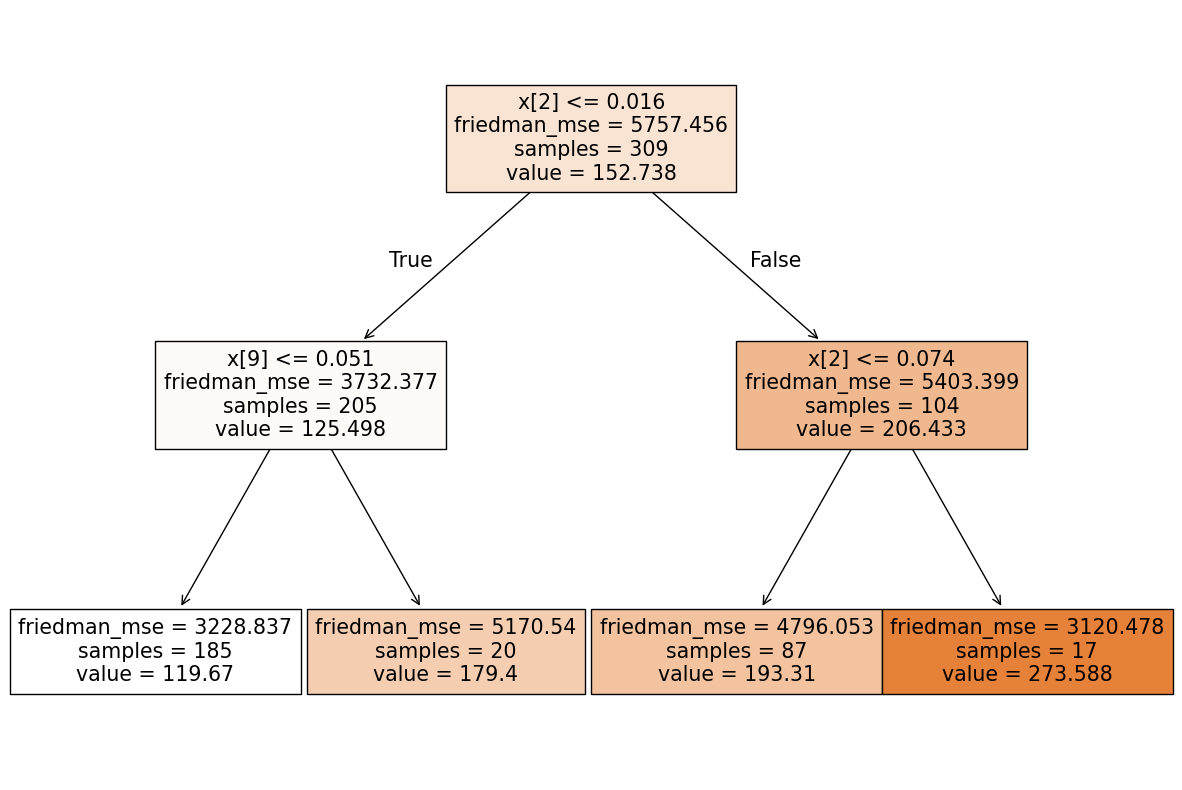

In [22]:
import matplotlib.pyplot as plt
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(selectedmodel,filled=True)